# Reading and mapping the GLEAM v4.3a zarr store

This notebook opens the icechunk-backed zarr store that `gleam_zarr.py` builds and
makes map plots from it with cartopy. It is a reader: every session here is
read-only and nothing writes back to the store.

The config supplies the download root and the store naming template, the same
ones the build and the verifier use, but *which* store to open is set in the
notebook: `VERSION`, `TEMPORAL_RESOLUTION`, `GRID_NAME` and `SUFFIX` below pick
one store out of that tree, so this notebook can be pointed at a finished store
without depending on what the config is currently building.

Sections:

1. Open the store and see what is in it
2. One day, one variable — a global map
3. The evaporation components on the same day
4. Monthly means, and a summer-minus-winter difference
5. A regional zoom on a projection that suits the region
6. The known data gap in `E`, on a map
7. Why a time series costs so much more than a map here

## 1. Open the store

`xr.open_zarr` reads the icechunk session's store rather than a directory path.
`consolidated=False` is required: icechunk keeps its own manifest and does not
write a consolidated zarr metadata document.

The four store settings are substituted into the config before `store_path` is
called, so the path is built by exactly the code the build uses — no second
spelling of the layout to keep in step.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import dask

from utils.path_utils import load_config, store_path

%matplotlib inline

CONFIG_PATH = 'config/config_zarr.yaml'

# which store to open. the config contributes only the download root and the
# filename template; these four fields are what select one store out of that
# tree, and they are set here so the notebook keeps reading a finished store
# whatever the config happens to be building.
VERSION = 'v4.3a'
TEMPORAL_RESOLUTION = 'daily'
GRID_NAME = 'native_0p1x0p1'
SUFFIX = 'spatial'

# only the 110m physical Natural Earth files are cached under
# ~/.local/share/cartopy on this machine, and a compute node cannot reach the
# download server, so every map here sticks to coastlines at that resolution.
# Borders, states and lakes would each trigger a fetch.
COASTLINE_RESOLUTION = '110m'

In [2]:
settings = load_config(CONFIG_PATH)

# the notebook, not the config, decides which store is opened; substituting the
# four fields before store_path reuses the config's download root and filename
# template while ignoring the identity of the store it is set up to build
settings['version'] = VERSION
settings['temporal_resolution'] = TEMPORAL_RESOLUTION
settings['grid_name'] = GRID_NAME
settings['output_conventions']['suffix'] = SUFFIX

path = store_path(settings)

# reading is thread bound the same way writing is; reuse the config's worker
# count so the notebook does not quietly oversubscribe the node it runs on
if settings.get('num_workers'):
    dask.config.set(num_workers=settings['num_workers'])

repository = icechunk.Repository.open(icechunk.local_filesystem_storage(path))
session = repository.readonly_session(branch='main')
ds = xr.open_zarr(session.store, consolidated=False)

snapshot = next(iter(repository.ancestry(branch='main')))
print(f'store    : {path}')
print(f'snapshot : {snapshot.id}  {snapshot.written_at:%Y-%m-%d %H:%M} UTC  "{snapshot.message}"')
ds

  2026-09-11T18:15:39.331730Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329



store    : /glade/derecho/scratch/kheyblom/data/gleam/v_4_3_a/zarr/gleam.v_4_3_a.daily.native_0p1x0p1.spatial.zarr
snapshot : N9M19WV4ZTGTPXBJA690  2026-09-10 19:23 UTC  "add provenance and discovery attributes"


<xarray.Dataset> Size: 6TB
Dimensions:  (time: 16802, lat: 1800, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * lat      (lat) float64 14kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
Data variables: (12/14)
    E        (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Es       (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Ep_rad   (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Eb       (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Ei       (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Ep_aero  (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    ...       ...
    H        (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    S        (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    SMrz     (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Ew       (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    SMs      (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    Et       (time, lat, lon) float32 436GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
Attributes: (12/29)
    Dataset:                    Global Land Evaporation Amsterdam Model
    Version:                    4.3a
    Authors:                    Hydro-Climate Extremes Lab (H-CEL)
    Institution:                Ghent University
    Contact:                    info@gleam.eu
    Reference1:                 Miralles, D.G. et al. 2025: global land evapo...
    ...                         ...
    creator_name:               Kyle Heyblom
    creator_email:              heyblom@umich.edu
    references:                 https://www.gleam.eu/ -- the dataset citation...
    chunking:                   Chunked (time, lat, lon) = (1, 1800, 3600), f...
    known_data_gaps:            Variable E is entirely fill (NaN) on 25 days ...
    verification:               Verified 2026-09-10 against the source netCDF...

A snapshot id pins a specific version of the store. Passing it to
`repository.readonly_session(snapshot_id=...)` instead of `branch='main'` reads
that exact state, which is what to do if a figure has to be reproducible against
a store that may be appended to later.

In [3]:
inventory = pd.DataFrame(
    [
        {
            'variable': name,
            'units': ds[name].attrs.get('units', ''),
            'long_name': ds[name].attrs.get('long_name', ''),
            'GiB': ds[name].nbytes / 1024**3,
        }
        for name in sorted(ds.data_vars)
    ]
).set_index('variable')

start, end = pd.Timestamp(ds.time.values[0]), pd.Timestamp(ds.time.values[-1])
print(f'time: {ds.time.size} days, {start:%Y-%m-%d} to {end:%Y-%m-%d}')
print(f'grid: {ds.lat.size} x {ds.lon.size} at {abs(float(ds.lat[1] - ds.lat[0])):.1f} degrees')
inventory

time: 16802 days, 1980-01-01 to 2025-12-31
grid: 1800 x 3600 at 0.1 degrees


,units,long_name,GiB
variable,,,
E,mm.day-1,Actual evaporation from GLEAM 4.3a,405.598283
Eb,mm.day-1,Bare soil evaporation from GLEAM 4.3a,405.598283
Ec,mm.day-1,Condensation from GLEAM 4.3a,405.598283
Ei,mm.day-1,Interception loss from GLEAM 4.3a,405.598283
Ep,mm.day-1,Potential evaporation from GLEAM 4.3a,405.598283
Ep_aero,mm.day-1,Potential evaporation from the aerodynamic com...,405.598283
Ep_rad,mm.day-1,Potential evaporation from the radiative compo...,405.598283
Es,mm.day-1,Snow sublimation from GLEAM 4.3a,405.598283
Et,mm.day-1,Transpiration from GLEAM 4.3a,405.598283


### What a read costs

The store is chunked `(time, lat, lon) = (1, 1800, 3600)`: **one chunk is one
whole global map**, 24.7 MiB of float32 compressed with zstd. That shape is the
whole cost model for reading it.

- A map of one variable on one day reads exactly one chunk. Cheap, always.
- Subsetting in space saves nothing. A chunk spans the full grid, so a map of
  Colorado on one day reads the same 24.7 MiB as a map of the world.
- Time is the only axis that changes what a read costs. Budget in **days
  requested x variables requested**, not in area.
- A point time series is the worst case: 46 years of one variable at one grid
  cell touches all 16,802 chunks of that variable, ~400 GiB, to return 16,802
  numbers. The store's own `chunking` attribute says as much, and says what to
  do instead — build a second store chunked along time.

Every cell below prints the number of chunks it reads so the cost stays visible.

In [4]:
CHUNK_MIB = ds['E'].data.nbytes / ds['E'].data.npartitions / 1024**2


def read_cost(*fields):
    """Report how many store chunks a pending computation will touch.

    Args:
        *fields (xr.DataArray | xr.Dataset): Lazy selections, before compute.

    Returns:
        str: A one line summary of chunk count and decompressed size.
    """
    arrays = [
        variable.data
        for field in fields
        for variable in (field.data_vars.values() if isinstance(field, xr.Dataset) else [field])
    ]
    n_chunks = sum(array.npartitions for array in arrays)
    return f'{n_chunks} chunks, ~{n_chunks * CHUNK_MIB / 1024:.1f} GiB decompressed'


print(f'one chunk = {CHUNK_MIB:.1f} MiB')

one chunk = 24.7 MiB


## 2. One day, one variable

`ds['E'].sel(time=DAY)` is lazy; nothing is read until `.compute()`. The helpers
below are used by every map in the notebook.

`imshow` rather than `pcolormesh`: the grid is a regular 0.1 degree lat/lon mesh,
so cartopy can warp it as an image instead of drawing 6.5 million quadrilaterals.
Measured on one global panel, `pcolormesh` took 64 s against well under a second
for the warp. Cartopy builds that warp with a KD-tree it does not bundle, which
is why `scipy` is a dependency of this project — without it, `imshow` onto
anything but `PlateCarree` raises. NaN covers both ocean and fill, and is drawn
in light grey.

In [5]:
def draw_map(field, ax, cmap='YlGnBu', vmin=None, vmax=None, extent=None):
    """Draw one lat/lon field on a cartopy axes.

    The field is drawn as a warped image rather than a quad mesh, which is
    correct here only because the grid is regular; it is also roughly an order
    of magnitude faster at 1800x3600.

    Args:
        field (xr.DataArray): A computed (lat, lon) slice.
        ax (cartopy.mpl.geoaxes.GeoAxes): Axes carrying the target projection.
        cmap (str): Colormap name; NaN is drawn light grey whatever it is.
        vmin (float): Low colour limit, or None to let matplotlib choose.
        vmax (float): High colour limit, or None to let matplotlib choose.
        extent (list): [west, east, south, north] in degrees to zoom to, or
            None for the whole globe.

    Returns:
        matplotlib.image.AxesImage: The mappable, for building a colorbar.
    """
    values = field.values
    lat = field['lat'].values
    lon = field['lon'].values

    # imshow lays rows out north to south; the store is stored that way already,
    # but a reversed .sel() slice would not be
    if lat[0] < lat[-1]:
        values = values[::-1]
        lat = lat[::-1]

    # coordinates are cell centres, so the image extent is half a cell wider
    half_lat = abs(float(lat[1] - lat[0])) / 2
    half_lon = abs(float(lon[1] - lon[0])) / 2
    image_extent = [
        lon[0] - half_lon, lon[-1] + half_lon,
        lat[-1] - half_lat, lat[0] + half_lat,
    ]

    palette = plt.get_cmap(cmap).copy()
    palette.set_bad('0.9')

    image = ax.imshow(
        values,
        extent=image_extent,
        origin='upper',
        transform=ccrs.PlateCarree(),
        cmap=palette,
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest',
    )
    ax.coastlines(resolution=COASTLINE_RESOLUTION, linewidth=0.4, color='0.35')
    if extent is None:
        ax.set_global()
    else:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    return image


def robust_limits(field, low=2.0, high=98.0, symmetric=False):
    """Colour limits from percentiles, so a few extreme cells cannot flatten a map.

    Args:
        field (xr.DataArray): A computed field; NaN cells are ignored.
        low (float): Lower percentile.
        high (float): Upper percentile.
        symmetric (bool): If True, return limits centred on zero, for a
            diverging colormap.

    Returns:
        tuple: (vmin, vmax).
    """
    finite = field.values[np.isfinite(field.values)]
    vmin, vmax = np.percentile(finite, [low, high])
    if symmetric:
        bound = max(abs(vmin), abs(vmax))
        return -bound, bound
    return float(vmin), float(vmax)


def label(name):
    """Axis or colorbar label for a variable, from its own attributes.

    Args:
        name (str): Variable name in the store.

    Returns:
        str: e.g. 'Actual evaporation from GLEAM 4.3a [mm.day-1]'.
    """
    attrs = ds[name].attrs
    return f"{attrs.get('long_name', name)} [{attrs.get('units', '')}]"

1 chunks, ~0.0 GiB decompressed


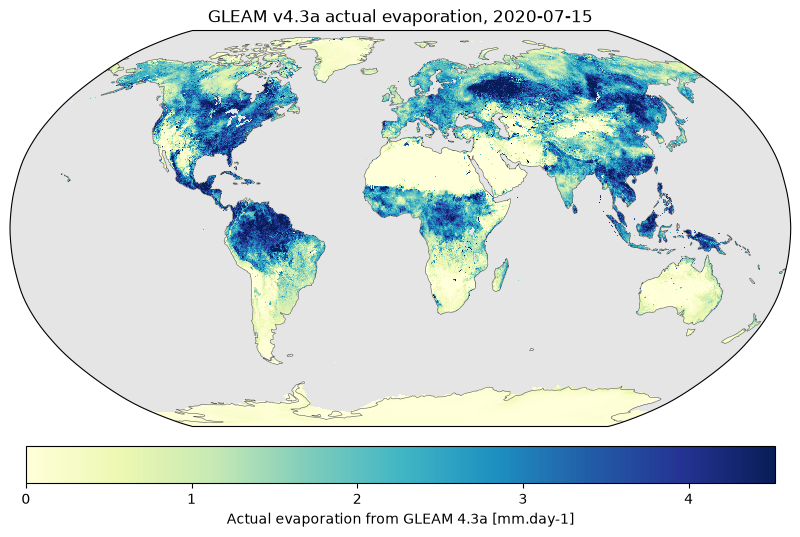

In [6]:
DAY = '2020-07-15'

daily_e = ds['E'].sel(time=DAY).squeeze()
print(read_cost(daily_e))
daily_e = daily_e.compute()

figure = plt.figure(figsize=(11, 5.5))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.Robinson())
image = draw_map(daily_e, ax, cmap='YlGnBu', vmin=0, vmax=robust_limits(daily_e)[1])
ax.set_title(f'GLEAM {VERSION} actual evaporation, {DAY}')
figure.colorbar(image, ax=ax, orientation='horizontal', pad=0.04, shrink=0.7,
                label=label('E'))
figure.tight_layout()

## 3. The evaporation components

`E` is the sum of its six components, and the verifier checks that identity
holds to float32 rounding, so these seven maps are consistent by construction.

Each panel gets **its own colour scale**, so the spatial structure of the small
terms is visible at all; on one shared scale transpiration swamps the other five
and they read as blank. The land-mean table underneath carries the magnitudes the
common scale would have shown, which is the honest way to have both.

The table also shows why a valid-cell mask has to be chosen deliberately here.
The components do not all share E's footprint — several are finite on a few
thousand cells where E is NaN — so averaging each over its own valid cells
compares different areas and the shares do not add up. Masking all of them to
E's footprint closes the sum to float32 rounding, which is the same identity
`verify_gleam_zarr.py` checks cell by cell.

6 chunks, ~0.1 GiB decompressed


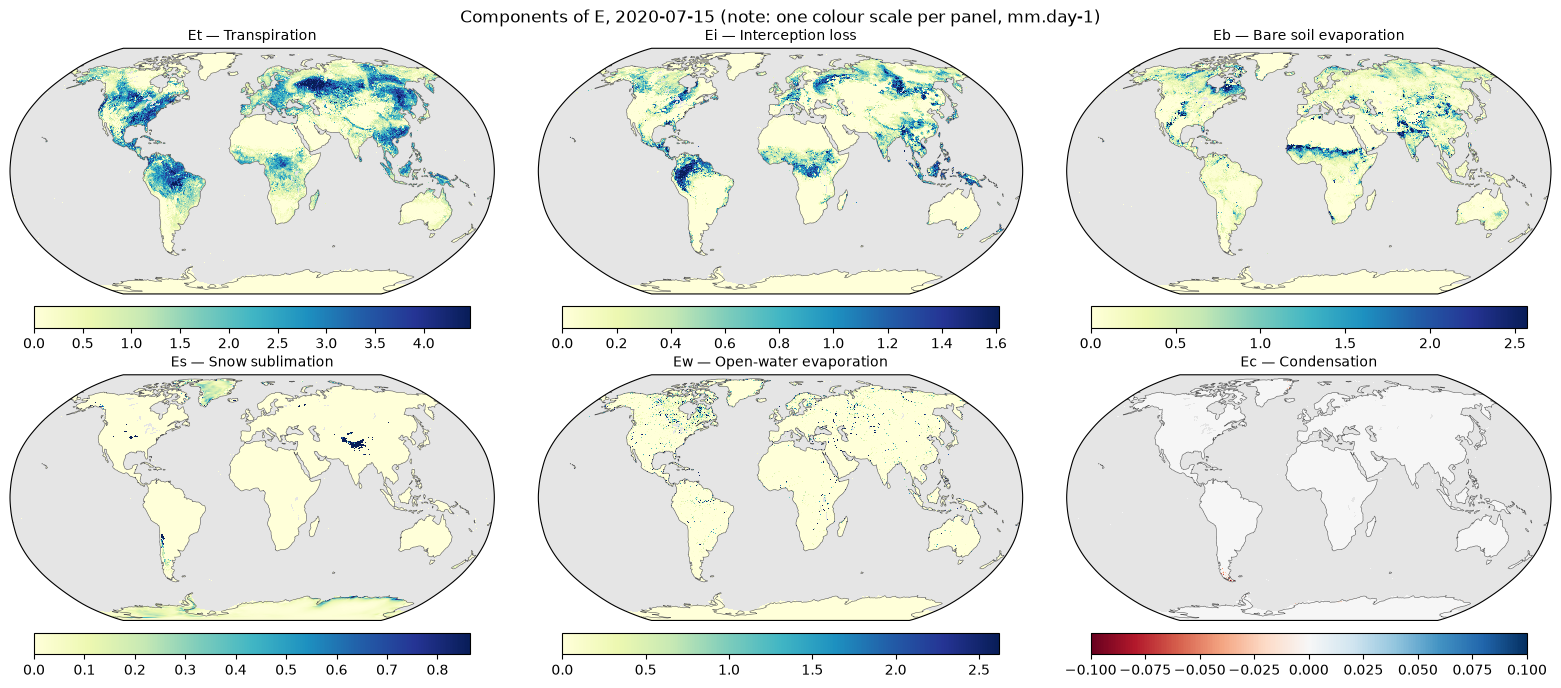

In [7]:
COMPONENTS = ['Et', 'Ei', 'Eb', 'Es', 'Ew', 'Ec']

components = ds[COMPONENTS].sel(time=DAY).squeeze()
print(read_cost(components))
components = components.compute()

figure, axes = plt.subplots(
    2, 3, figsize=(16, 7), subplot_kw={'projection': ccrs.Robinson()}
)
for name, ax in zip(COMPONENTS, axes.ravel()):
    field = components[name]
    # Ec is condensation and runs negative, so it needs a diverging scale
    # centred on zero rather than the sequential one the other five use
    diverging = float(field.min()) < 0
    vmin, vmax = robust_limits(field, low=1, high=99.5, symmetric=diverging)
    image = draw_map(field, ax, cmap='RdBu' if diverging else 'YlGnBu',
                     vmin=vmin if diverging else 0, vmax=vmax)
    ax.set_title(f"{name} — {ds[name].attrs['long_name'].split(' from ')[0]}", fontsize=10)
    figure.colorbar(image, ax=ax, orientation='horizontal', pad=0.04, shrink=0.85)

figure.suptitle(f'Components of E, {DAY} (note: one colour scale per panel, mm.day-1)')
figure.tight_layout()

In [8]:
def land_mean(field):
    """Area-weighted mean over the cells that carry data.

    Grid cells shrink towards the poles, so an unweighted mean over a lat/lon
    grid over-counts high latitudes; cos(lat) is the weight that corrects it.
    NaN cells -- ocean, and any fill -- drop out of both sums.

    Args:
        field (xr.DataArray): A computed (lat, lon) field.

    Returns:
        float: The area-weighted mean of the finite cells.
    """
    weights = np.cos(np.deg2rad(field['lat']))
    return float(field.weighted(weights).mean(['lat', 'lon']))


# Et, Eb, Es and Ec carry data on a few thousand cells where E itself is NaN.
# weighted().mean() renormalises over whatever cells are finite, so averaging
# each variable over its own footprint compares them on different areas and the
# shares come out not summing to 100. Restricting every component to the cells
# where E is finite is what makes the comparison an equal footing one.
footprint = daily_e.notnull()
wider = {
    name: int((components[name].notnull() & ~footprint).sum()) for name in COMPONENTS
}
print(f'cells with component data but no E: {wider}')

totals = pd.DataFrame(
    [
        {'component': name,
         'land mean [mm/day]': land_mean(components[name].where(footprint)),
         'share of E [%]': (100 * land_mean(components[name].where(footprint))
                            / land_mean(daily_e))}
        for name in COMPONENTS
    ]
).set_index('component')
totals.loc['sum of components'] = [
    totals['land mean [mm/day]'].sum(), totals['share of E [%]'].sum()
]
totals.loc['E'] = [land_mean(daily_e), 100.0]

print(f'land-mean components against E, {DAY}')
totals.round(4)

cells with component data but no E: {'Et': 5488, 'Ei': 1, 'Eb': 5488, 'Es': 5258, 'Ew': 0, 'Ec': 5488}


land-mean components against E, 2020-07-15


,land mean [mm/day],share of E [%]
component,,
Et,1.0218,62.4326
Ei,0.2312,14.1261
Eb,0.2813,17.1849
Es,0.0219,1.3362
Ew,0.0806,4.9229
Ec,-0.0000,-0.0026
sum of components,1.6367,100.0000
E,1.6367,100.0000


## 4. Monthly means and a seasonal difference

This is the first cell that costs real I/O: a month of one variable is ~31
chunks. The two months are loaded once here and reused by the plots that follow,
so nothing below reads the store again.

In [9]:
SUMMER = '2020-07'
WINTER = '2020-01'

summer_lazy = ds[['E', 'SMrz', 'S']].sel(time=SUMMER).mean('time', keep_attrs=True)
winter_lazy = ds[['E']].sel(time=WINTER).mean('time', keep_attrs=True)
print(read_cost(ds[['E', 'SMrz', 'S']].sel(time=SUMMER), ds[['E']].sel(time=WINTER)))

summer = summer_lazy.compute()
winter = winter_lazy.compute()

124 chunks, ~3.0 GiB decompressed


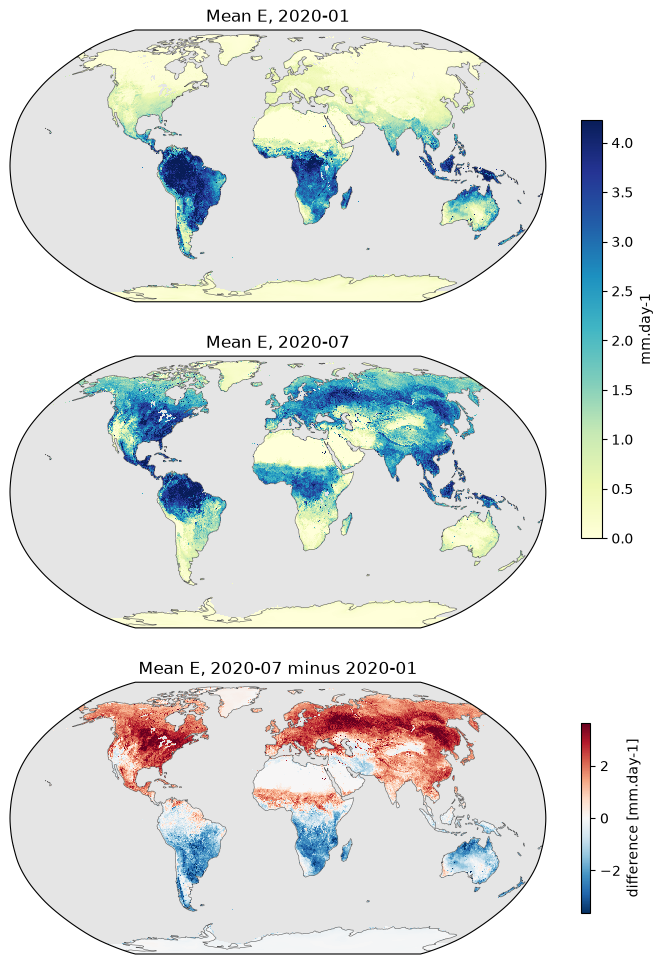

In [10]:
difference = summer['E'] - winter['E']
bound = robust_limits(difference, low=1, high=99, symmetric=True)[1]

figure, axes = plt.subplots(
    3, 1, figsize=(9, 12), subplot_kw={'projection': ccrs.Robinson()}
)

evaporation_max = robust_limits(summer['E'], high=99)[1]
for ax, field, month in ((axes[0], winter['E'], WINTER), (axes[1], summer['E'], SUMMER)):
    image = draw_map(field, ax, cmap='YlGnBu', vmin=0, vmax=evaporation_max)
    ax.set_title(f'Mean E, {month}')
figure.colorbar(image, ax=axes[:2], orientation='vertical', shrink=0.7, label='mm.day-1')

image = draw_map(difference, axes[2], cmap='RdBu_r', vmin=-bound, vmax=bound)
axes[2].set_title(f'Mean E, {SUMMER} minus {WINTER}')
figure.colorbar(image, ax=axes[2], orientation='vertical', shrink=0.7,
                label='difference [mm.day-1]')

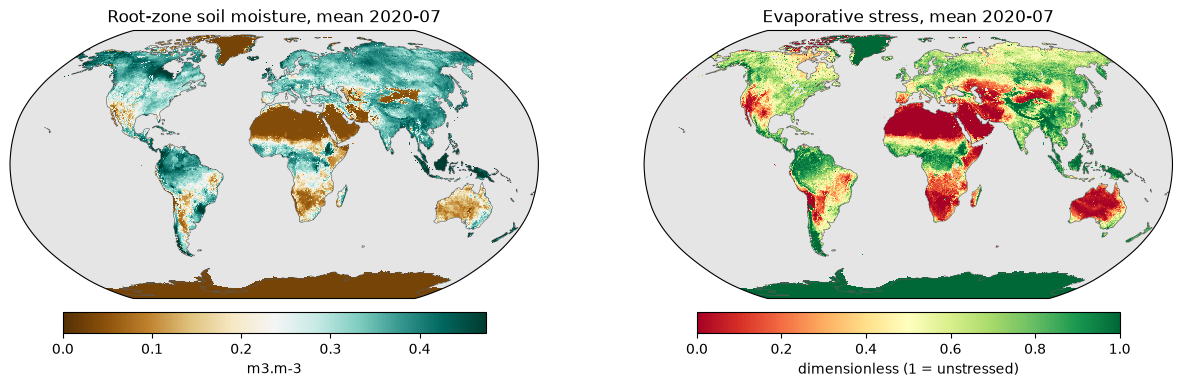

In [11]:
figure, axes = plt.subplots(
    1, 2, figsize=(15, 4.5), subplot_kw={'projection': ccrs.Robinson()}
)

image = draw_map(summer['SMrz'], axes[0], cmap='BrBG', vmin=0,
                 vmax=robust_limits(summer['SMrz'], high=99)[1])
axes[0].set_title(f'Root-zone soil moisture, mean {SUMMER}')
figure.colorbar(image, ax=axes[0], orientation='horizontal', pad=0.04, shrink=0.8,
                label=ds['SMrz'].attrs['units'])

image = draw_map(summer['S'], axes[1], cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title(f'Evaporative stress, mean {SUMMER}')
figure.colorbar(image, ax=axes[1], orientation='horizontal', pad=0.04, shrink=0.8,
                label='dimensionless (1 = unstressed)')

## 5. A regional zoom

Subsetting in space costs nothing extra *and saves nothing*: the July means are
already in memory, so this is pure plotting. Note the latitude slice runs north
to south, matching the store's descending `lat` coordinate — `slice(24, 50)`
would return an empty selection.

An equal-area conic projection suits a mid-latitude region better than Robinson.
Only coastlines are drawn: state and country boundaries live in Natural Earth's
cultural files, which are not cached here.

Text(0.5, 0.98, 'contiguous United States')

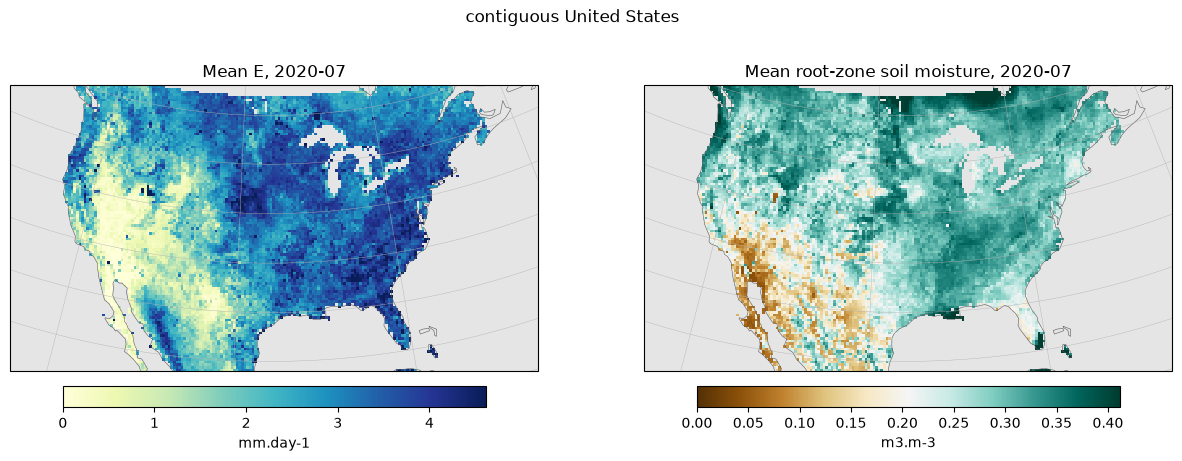

In [12]:
REGION = {'name': 'contiguous United States',
          'extent': [-125, -66, 24, 50],
          'lat': slice(52, 22), 'lon': slice(-127, -64)}

projection = ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))
figure, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': projection})

regional_e = summer['E'].sel(lat=REGION['lat'], lon=REGION['lon'])
image = draw_map(regional_e, axes[0], cmap='YlGnBu', vmin=0,
                 vmax=robust_limits(regional_e, high=99)[1], extent=REGION['extent'])
axes[0].set_title(f'Mean E, {SUMMER}')
figure.colorbar(image, ax=axes[0], orientation='horizontal', pad=0.04, shrink=0.8,
                label='mm.day-1')

regional_sm = summer['SMrz'].sel(lat=REGION['lat'], lon=REGION['lon'])
image = draw_map(regional_sm, axes[1], cmap='BrBG', vmin=0,
                 vmax=robust_limits(regional_sm, high=99)[1], extent=REGION['extent'])
axes[1].set_title(f'Mean root-zone soil moisture, {SUMMER}')
figure.colorbar(image, ax=axes[1], orientation='horizontal', pad=0.04, shrink=0.8,
                label='m3.m-3')

for ax in axes:
    ax.gridlines(draw_labels=False, linewidth=0.3, color='0.7')
figure.suptitle(REGION['name'])

## 6. The known gap in `E`

`E` is entirely fill on 25 days — five 5-day blocks in 1982 and 1992 — while
every other variable, including E's own components, has data on those days. That
is a gap in upstream GLEAM v4.3a, not a conversion defect, and it is recorded in
the store's `known_data_gaps` attribute. Zarr does not write a chunk whose cells
are all fill, so `E` holds 16,777 chunks against 16,802 timesteps and that is
correct: the missing chunk reads back as NaN.

Worth knowing before an average over 1992 comes out looking odd. `E.isnull()`
finds the gap days cheaply only if you already know where to look — the attribute
is the cheap route.

Variable E is entirely fill (NaN) on 25 days -- five 5-day blocks, 1982-02-05..02-09 and 1992-01-01..01-05, 03-21..03-25, 05-20..05-24 and 10-02..10-06 -- while every other variable, including E's own components, has data on those days. This is a gap in upstream GLEAM v4.3a, not a conversion defect. Zarr does not write a chunk whose cells are all fill, so E holds 16777 chunks against 16802 timesteps and that is correct.
2 chunks, ~0.0 GiB decompressed


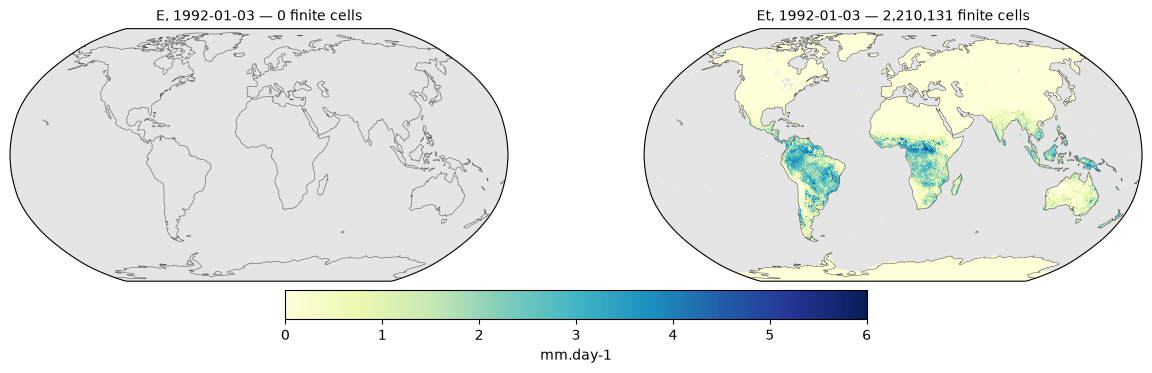

In [13]:
print(ds.attrs['known_data_gaps'])

GAP_DAY = '1992-01-03'

gap = ds[['E', 'Et']].sel(time=GAP_DAY).squeeze()
print(read_cost(gap))
gap = gap.compute()

figure, axes = plt.subplots(
    1, 2, figsize=(15, 4), subplot_kw={'projection': ccrs.Robinson()}
)
for ax, name in zip(axes, ['E', 'Et']):
    finite = int(np.isfinite(gap[name].values).sum())
    image = draw_map(gap[name], ax, cmap='YlGnBu', vmin=0, vmax=6)
    ax.set_title(f'{name}, {GAP_DAY} — {finite:,} finite cells', fontsize=10)
figure.colorbar(image, ax=axes, orientation='horizontal', pad=0.03, shrink=0.5,
                label='mm.day-1')

## 7. What a time series costs

Here is the cost model from section 1 made concrete. This regional daily mean
covers 60 days of one variable, so it reads 60 whole global chunks — about 1.5
GiB — to produce 60 numbers, and clipping to a region does not reduce that by a
single byte.

Sixty days is affordable. The same call over the full 46-year record would read
~400 GiB. If point or regional time series are the main access pattern, the
answer is a second store chunked along time, not a longer wait on this one.

60 chunks, ~1.4 GiB decompressed


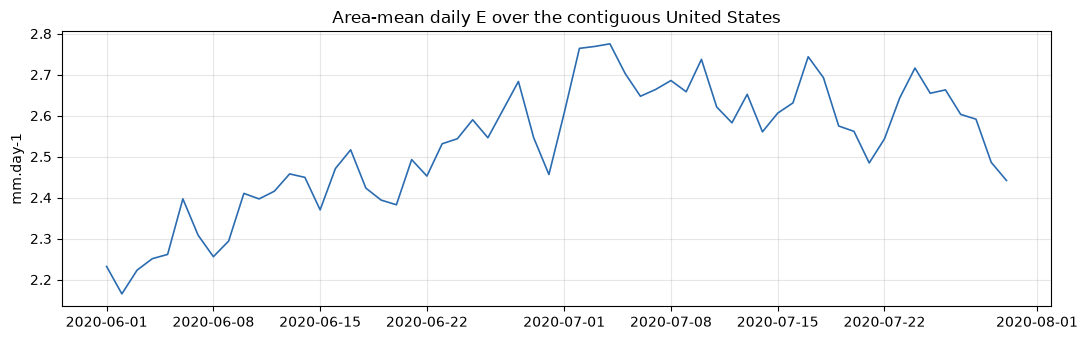

In [14]:
WINDOW = slice('2020-06-01', '2020-07-30')

regional = ds['E'].sel(time=WINDOW, lat=REGION['lat'], lon=REGION['lon'])
# cos(lat) weighted, the same as land_mean above, but vectorised over time
# rather than applied a day at a time; weighted().mean() drops NaN cells and
# renormalises, so ocean and any fill stay out of the average
weights = np.cos(np.deg2rad(regional['lat']))
series_lazy = regional.weighted(weights).mean(['lat', 'lon'])

# the cost is set by the time slice alone: the lat/lon selection happens after
# each whole global chunk has already been read and decompressed
print(read_cost(ds['E'].sel(time=WINDOW)))

series = series_lazy.compute()

figure, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(series['time'], series.values, color='#2b6cb0', linewidth=1.2)
ax.set_ylabel('mm.day-1')
ax.set_title(f"Area-mean daily E over the {REGION['name']}")
ax.grid(alpha=0.3)
figure.tight_layout()

---

### Next steps

- `verify_gleam_zarr.py --config config/config_zarr.yaml --phases sweep` audits all
  235,228 chunks off the manifest in ~30 s, without reading data. It is the thing
  to run after any rebuild, and `TESTING.md` records what the full audit found.
- Pin figures to a snapshot id (section 1) rather than to `branch='main'` if the
  store may be appended to.
- Anything time-series heavy wants a second store chunked along time; this one is
  built for maps and fields.